In [1]:
# Importing 
import pandas as pd
import matplotlib.pyplot as plt 
import os

In [2]:
# Importing data from kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("missionjee/car-sales-report")

print("Path to dataset files:", path)


Path to dataset files: /Users/kristinapavlovska/.cache/kagglehub/datasets/missionjee/car-sales-report/versions/1


In [3]:
data = pd.read_csv(path + "/Car Sales.xlsx - car_data.csv")
data.head(10)

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville
5,C_CND_000006,1/2/2022,Guadalupe,Male,850000,Classic Chevy,Mitsubishi,Diamante,Overhead Camshaft,Manual,Pale White,12000,85257-3102,Hatchback,7315216,Scottsdale
6,C_CND_000007,1/2/2022,Hailey,Male,1600000,Clay Johnson Auto Sales,Toyota,Corolla,Overhead Camshaft,Manual,Pale White,14000,78758-7841,Passenger,7727879,Austin
7,C_CND_000008,1/2/2022,Graham,Male,13500,U-Haul CO,Mitsubishi,Galant,DoubleÂ Overhead Camshaft,Auto,Pale White,42000,78758-7841,Passenger,6206512,Austin
8,C_CND_000009,1/2/2022,Naomi,Male,815000,Rabun Used Car Sales,Chevrolet,Malibu,Overhead Camshaft,Manual,Pale White,82000,85257-3102,Hardtop,7194857,Pasco
9,C_CND_000010,1/2/2022,Grayson,Female,13500,Rabun Used Car Sales,Ford,Escort,DoubleÂ Overhead Camshaft,Auto,Pale White,15000,85257-3102,Passenger,7836892,Scottsdale


In [9]:
data["Gender"].value_counts()

Gender
Male      18798
Female     5108
Name: count, dtype: int64

In [20]:
data.groupby(["Company", "Gender"]).size().unstack()
per_female = data.groupby("Company")["Gender"].apply(lambda x: (x == "Female").sum() / len(x) * 100)
print(per_female)
print(f"Firma gdzie największa ilość kobiet: {per_female.idxmax()}, gdzie: {per_female.max()}%")

Company
Acura         24.238026
Audi          18.376068
BMW           21.392405
Buick         19.817768
Cadillac      23.466258
Chevrolet     21.330401
Chrysler      21.964286
Dodge         20.586475
Ford          22.738538
Honda         22.598870
Hyundai       19.696970
Infiniti      17.948718
Jaguar        17.222222
Jeep          18.457300
Lexus         20.947631
Lincoln       21.544715
Mercedes-B    22.723735
Mercury       18.192220
Mitsubishi    21.064996
Nissan        23.476298
Oldsmobile    19.621962
Plymouth      21.880065
Pontiac       22.989950
Porsche       23.268698
Saab          21.904762
Saturn        23.208191
Subaru        17.283951
Toyota        20.000000
Volkswagen    21.680420
Volvo         21.673004
Name: Gender, dtype: float64
Firma gdzie największa ilość kobiet: Acura, gdzie: 24.238026124818575%


<Axes: xlabel='Company'>

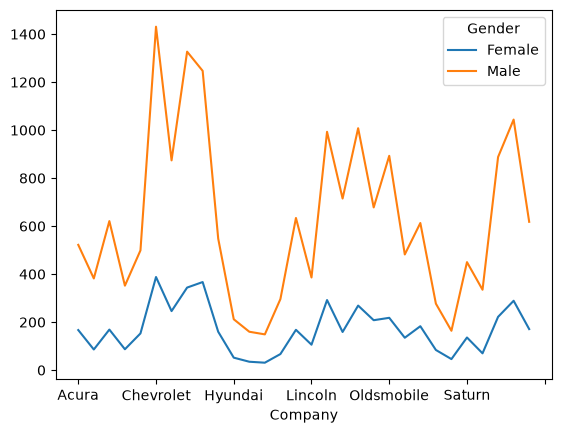

In [10]:
pd.crosstab(data["Company"],data["Gender"]).plot()